In [2]:
from matplotlib import pyplot as plt
import seaborn as sns
import platform

# OS에 맞춰 한글 폰트 자동 설정
if platform.system() == 'Darwin': # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
# 마이너스기호 깨짐 방지
plt.rc('axes', unicode_minus=False)
# Seaborn 기본 스타일설정
sns.set_theme(style="whitegrid", font="AppleGothic" if platform.system() == 'Darwin' else "Malgun Gothic")

In [3]:
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

c:\ML_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
df = pd.read_csv("Oworld.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

target = "visitors"

feature_cols = [c for c in df.columns if c not in ["date", "weekend", target]]

X = df[feature_cols]
y = df[target]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=1.0, random_state=42, max_iter=10000),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=500, max_depth=None, random_state=42, n_jobs=-1
    ),
    "SVR": SVR(kernel="rbf", C=100, gamma="scale", epsilon=50),
    "XGBoost": XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500, max_depth=-1, learning_rate=0.01,
        random_state=42, verbosity=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500, depth=10, learning_rate=0.01,
        random_state=42, verbose=0
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=8, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42
    ),
}

results = []
predictions = {}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print(results_df)

                Model         RMSE          MAE        R2
0            CatBoost  1313.257573   806.589909  0.673038
1       Random Forest  1342.781801   830.716664  0.658171
2             XGBoost  1351.365606   845.240417  0.653787
3            LightGBM  1354.981493   858.599132  0.651932
4   Gradient Boosting  1381.077294   852.444057  0.638395
5       Decision Tree  1567.735505   900.211152  0.534046
6   Linear Regression  1675.988547  1194.206683  0.467475
7    Lasso Regression  1676.420103  1193.908774  0.467201
8    Ridge Regression  1676.816200  1194.164751  0.466949
9          ElasticNet  2104.289783  1570.797065  0.160523
10                SVR  2479.165335  1485.222893 -0.165223


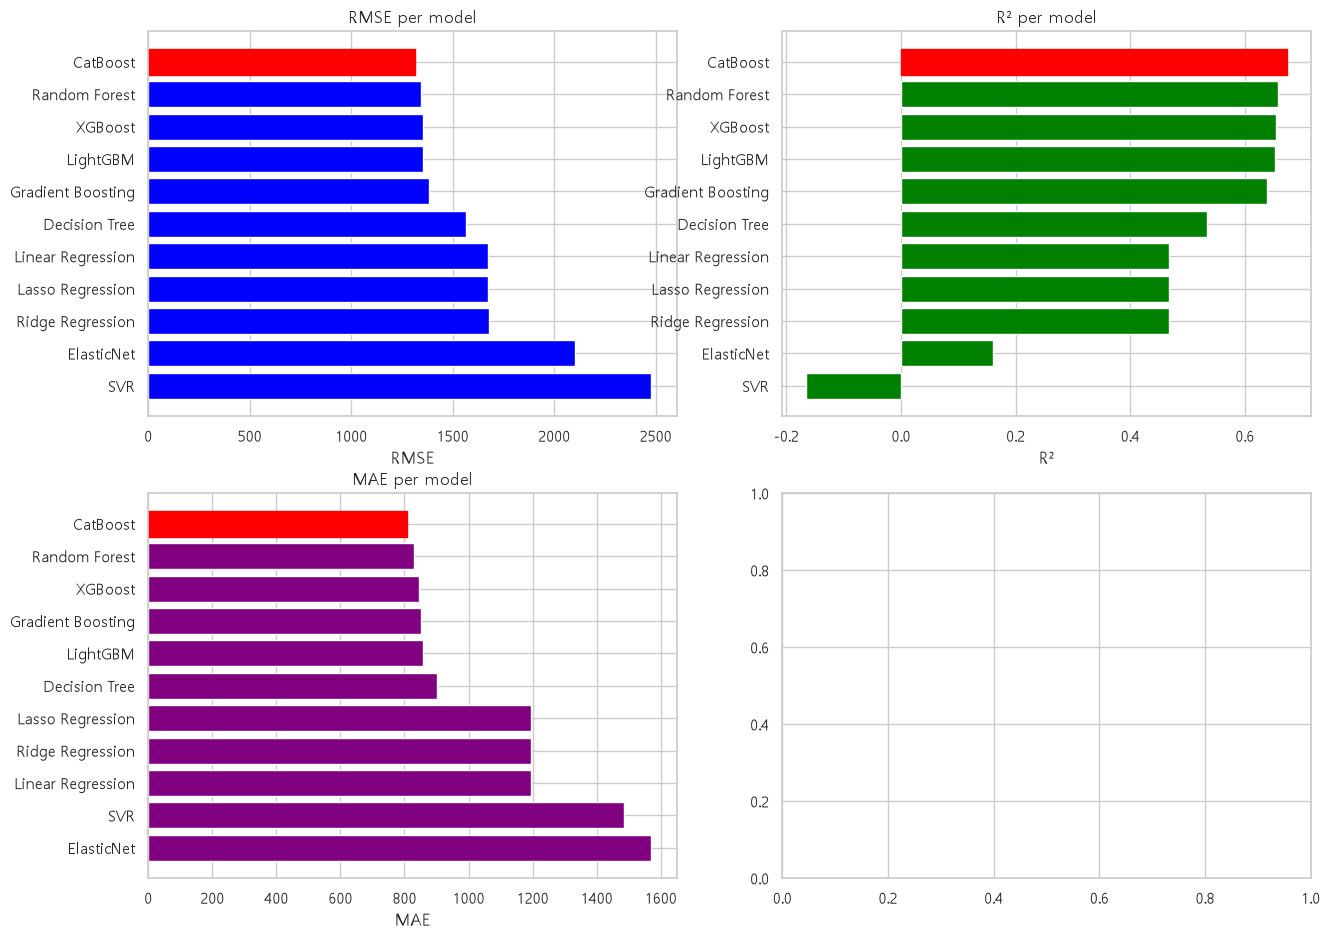

In [36]:
results_df = results_df.sort_values("RMSE")
 
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
 
# (1) RMSE 비교
ax = axes[0, 0]
bars = ax.barh(results_df["Model"], results_df["RMSE"], color="blue")
bars[0].set_color("red")
ax.set_xlabel("RMSE")
ax.set_title("RMSE per model")
ax.invert_yaxis()
 
# (2) R2 비교
ax = axes[0, 1]
results_sorted_r2 = results_df.sort_values("R2", ascending=False)
bars = ax.barh(results_sorted_r2["Model"], results_sorted_r2["R2"], color="green")
bars[0].set_color("red")
ax.set_xlabel("R²")
ax.set_title("R² per model")
ax.invert_yaxis()
 
# (3) MAE 비교
ax = axes[1, 0]
results_sorted_mae = results_df.sort_values("MAE")
bars = ax.barh(results_sorted_mae["Model"], results_sorted_mae["MAE"], color="purple")
bars[0].set_color("red")
ax.set_xlabel("MAE")
ax.set_title("MAE per model")
ax.invert_yaxis()

In [38]:
files = ["test1.csv", "test1_cat.csv", "test2.csv", "test2_cat.csv",
         "test3.csv", "test3_cat.csv", "test4.csv", "test4_cat.csv"]

for file in files:
    df = pd.read_csv(file)

    target = "visitors"

    feature_cols = [c for c in df.columns if c not in [target]]
    cat_features = ["month"]

    X = df[feature_cols]
    y = df[target]

    split_idx = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = CatBoostRegressor(
            iterations=500, depth=10, learning_rate=0.01,
            random_state=42, verbose=0
        )
   
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_test = y_test
    print(file)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print("test1")
    print(f"  MAE : {mae:,.1f} visitors")
    print(f"  RMSE: {rmse:,.1f} visitors")
    print(f"  R2  : {r2:.3f}")

test1.csv
test1
  MAE : 687.7 visitors
  RMSE: 1,145.0 visitors
  R2  : 0.751
test1_cat.csv
test1
  MAE : 711.7 visitors
  RMSE: 1,174.2 visitors
  R2  : 0.739
test2.csv
test1
  MAE : 693.6 visitors
  RMSE: 1,162.0 visitors
  R2  : 0.744
test2_cat.csv
test1
  MAE : 730.3 visitors
  RMSE: 1,212.7 visitors
  R2  : 0.721
test3.csv
test1
  MAE : 735.7 visitors
  RMSE: 1,212.9 visitors
  R2  : 0.721
test3_cat.csv
test1
  MAE : 768.7 visitors
  RMSE: 1,260.2 visitors
  R2  : 0.699
test4.csv
test1
  MAE : 757.6 visitors
  RMSE: 1,257.8 visitors
  R2  : 0.700
test4_cat.csv
test1
  MAE : 793.1 visitors
  RMSE: 1,301.5 visitors
  R2  : 0.679


In [ ]:
df = pd.read_csv("test1_cat.csv")

target = "visitors"

feature_cols = [c for c in df.columns if c not in [target]]

X = df[feature_cols]
y = np.log1p(df[target])

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 5.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_state": 42,
        "verbose": 0,
    }

    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = CatBoostRegressor(**params, early_stopping_rounds=50)
        m.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
        pred = np.expm1(m.predict(X_val))
        actual = np.expm1(y_val)
        scores.append(mean_absolute_error(actual, pred))
    return np.mean(scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)
print(study.best_params, study.best_value)

[I 2026-08-13 09:47:24,350] A new study created in memory with name: no-name-477f4acc-7b8f-470d-9b67-f29cb3fc167b
Best trial: 0. Best value: 804.778:   2%|▏         | 1/50 [01:50<1:29:52, 110.06s/it]

[I 2026-08-13 09:49:14,407] Trial 0 finished with value: 804.7779250920445 and parameters: {'iterations': 1187, 'depth': 7, 'learning_rate': 0.006523276099439469, 'l2_leaf_reg': 8.095811696498084, 'bagging_temperature': 1.7509038036144235, 'random_strength': 0.3145701218434549, 'border_count': 160}. Best is trial 0 with value: 804.7779250920445.


Best trial: 1. Best value: 788.797:   4%|▍         | 2/50 [03:35<1:25:52, 107.34s/it]

[I 2026-08-13 09:50:59,854] Trial 1 finished with value: 788.7965171208818 and parameters: {'iterations': 1503, 'depth': 8, 'learning_rate': 0.009197693169029906, 'l2_leaf_reg': 1.397552238741455, 'bagging_temperature': 2.5871786890236392, 'random_strength': 0.5173912308303802, 'border_count': 185}. Best is trial 1 with value: 788.7965171208818.


Best trial: 2. Best value: 770.886:   6%|▌         | 3/50 [03:43<48:38, 62.10s/it]   

...

[I 2026-08-13 10:43:38,650] Trial 47 finished with value: 776.0969373161912 and parameters: {'iterations': 1404, 'depth': 9, 'learning_rate': 0.03202187129261253, 'l2_leaf_reg': 12.287713721238381, 'bagging_temperature': 0.5284314209945049, 'random_strength': 0.017370600245365346, 'border_count': 52}. Best is trial 45 with value: 758.6071384470697.


Best trial: 45. Best value: 758.607:  98%|█████████▊| 49/50 [56:56<01:03, 63.81s/it]

[I 2026-08-13 10:44:21,125] Trial 48 finished with value: 785.0023956305189 and parameters: {'iterations': 1139, 'depth': 8, 'learning_rate': 0.055068073930950194, 'l2_leaf_reg': 7.75435631926639, 'bagging_temperature': 0.08062972234278432, 'random_strength': 0.7406601431505713, 'border_count': 32}. Best is trial 45 with value: 758.6071384470697.


Best trial: 45. Best value: 758.607: 100%|██████████| 50/50 [57:24<00:00, 68.89s/it]

[I 2026-08-13 10:44:49,014] Trial 49 finished with value: 792.1351443130119 and parameters: {'iterations': 1276, 'depth': 7, 'learning_rate': 0.07469868213147732, 'l2_leaf_reg': 6.71445732061741, 'bagging_temperature': 0.8694300984611636, 'random_strength': 1.5930639374679352, 'border_count': 47}. Best is trial 45 with value: 758.6071384470697.
{'iterations': 1164, 'depth': 8, 'learning_rate': 0.04585878172511418, 'l2_leaf_reg': 8.928840273173956, 'bagging_temperature': 0.9065380504018735, 'random_strength': 0.051733258645387664, 'border_count': 49} 758.6071384470697


0:	learn: 2492.1713043	total: 2.49ms	remaining: 2.9s
1:	learn: 2430.1716886	total: 4.75ms	remaining: 2.76s
2:	learn: 2373.9247087	total: 7.25ms	remaining: 2.8s
3:	learn: 2317.9104443	total: 10.3ms	remaining: 2.98s
4:	learn: 2268.2958136	total: 12.3ms	remaining: 2.85s
5:	learn: 2218.1293219	total: 14.6ms	remaining: 2.82s
6:	learn: 2172.5030178	total: 17.1ms	remaining: 2.82s
7:	learn: 2126.7655804	total: 18.8ms	remaining: 2.71s
8:	learn: 2087.0906770	total: 21.1ms	remaining: 2.71s
9:	learn: 2046.7378879	total: 23ms	remaining: 2.65s
10:	learn: 2003.5252171	total: 24.7ms	remaining: 2.59s
11:	learn: 1966.1235273	total: 26.4ms	remaining: 2.53s
12:	learn: 1928.0344703	total: 27.8ms	remaining: 2.46s
13:	learn: 1895.3044826	total: 29ms	remaining: 2.38s
14:	learn: 1863.0154282	total: 30.3ms	remaining: 2.32s
15:	learn: 1833.9349214	total: 31.5ms	remaining: 2.26s
16:	learn: 1805.6634097	total: 32.9ms	remaining: 2.22s
17:	learn: 1775.8920172	total: 34.8ms	remaining: 2.21s
18:	learn: 1741.7101641	to

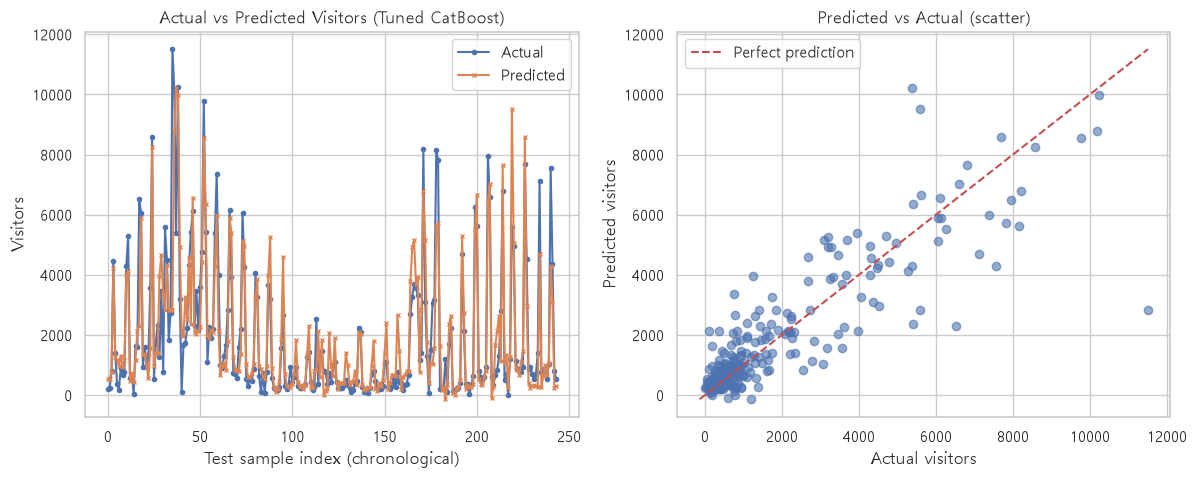

In [ ]:
df = pd.read_csv("test1.csv")

target = "visitors"

feature_cols = [c for c in df.columns if c not in [target]]

X = df[feature_cols]
y = df[target]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

model = CatBoostRegressor(
    **study.best_params, random_state=42, early_stopping_rounds=50)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"  MAE : {mae:,.1f} visitors")
print(f"  RMSE: {rmse:,.1f} visitors")
print(f"  R2  : {r2:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(y_test.values, label="Actual", marker="o", markersize=3)
axes[0].plot(y_pred, label="Predicted", marker="x", markersize=3)
axes[0].set_title("Actual vs Predicted Visitors (Tuned CatBoost)")
axes[0].set_xlabel("Test sample index (chronological)")
axes[0].set_ylabel("Visitors")
axes[0].legend()
 
axes[1].scatter(y_test, y_pred, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, "r--", label="Perfect prediction")
axes[1].set_title("Predicted vs Actual (scatter)")
axes[1].set_xlabel("Actual visitors")
axes[1].set_ylabel("Predicted visitors")
axes[1].legend()
'''
example = pd.DataFrame([{
    "dayoff": 0,
    "nextdayoff": 0,
    "month":1,
    "temperature": 15.0,
    "rain": 0.7,
    "humidity": 55.0,
}])[feature_cols]
 
example_pred = model.predict(example)[0]
print(f"\nExample prediction for a hypothetical day: {example_pred-653:,.0f} ~ {example_pred+653:,.0f}visitors")
'''
model.save_model("visitor_estimation_model.cbm")

In [13]:
example = pd.read_csv("random_data.csv")
example["rain"] = np.random.randint(0, 101, size = len(example))

# Run prediction once on all rows
predictions = model.predict(example)

for i in range(len(example)):
    example_pred = predictions[i]
    print(f"\nExample prediction for day {i}: {max(0, example_pred-653):,.0f} ~ {example_pred+653:,.0f} visitors")


Example prediction for day 0: 4,624 ~ 5,930 visitors

Example prediction for day 1: 1,580 ~ 2,886 visitors

Example prediction for day 2: 5,600 ~ 6,906 visitors

Example prediction for day 3: 1,543 ~ 2,849 visitors

Example prediction for day 4: 2,408 ~ 3,714 visitors

Example prediction for day 5: 3,469 ~ 4,775 visitors

Example prediction for day 6: 876 ~ 2,182 visitors

Example prediction for day 7: 1,376 ~ 2,682 visitors

Example prediction for day 8: 5,038 ~ 6,344 visitors

Example prediction for day 9: 658 ~ 1,964 visitors

Example prediction for day 10: 1,433 ~ 2,739 visitors

Example prediction for day 11: 1,001 ~ 2,307 visitors

Example prediction for day 12: 401 ~ 1,707 visitors

Example prediction for day 13: 273 ~ 1,579 visitors

Example prediction for day 14: 6,474 ~ 7,780 visitors

Example prediction for day 15: 1,085 ~ 2,391 visitors

Example prediction for day 16: 0 ~ 1,051 visitors

Example prediction for day 17: 5,834 ~ 7,140 visitors

Example prediction for day 18: 